Скачайте данные по ссылке (https://code.s3.yandex.net/deep-learning/faces.zip) и расположите их по пути data/faces/..

In [1]:
import requests
import zipfile
import os

def download_and_extract_zip(url, extract_path, zip_filename='downloaded_file.zip'):
    """
    Скачивает ZIP-файл по URL и распаковывает его в указанную директорию.

    Параметры:
    - url (str): URL для скачивания ZIP-файла.
    - extract_path (str): путь к директории для распаковки.
    - zip_filename (str): имя файла для сохранения скачанного архива.
    """
    try:
        # Создаём директорию для распаковки, если её нет
        os.makedirs(extract_path, exist_ok=True)

        # Скачиваем файл
        print("Скачивание файла...")
        response = requests.get(url, stream=True)
        response.raise_for_status()  # Проверяем, что запрос успешен

        # Сохраняем скачанный файл
        zip_path = os.path.join(extract_path, zip_filename)
        with open(zip_path, 'wb') as file:
            for chunk in response.iter_content(chunk_size=8192):
                file.write(chunk)
        print(f"Файл успешно скачан: {zip_path}")

        # Распаковываем архив
        print("Распаковка архива...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print(f"Архив успешно распакован в: {extract_path}")

        # Удаляем ZIP-файл после распаковки (опционально)
        os.remove(zip_path)
        print("Временный ZIP-файл удалён.")

    except requests.exceptions.RequestException as e:
        print(f"Ошибка при скачивании: {e}")
    except zipfile.BadZipFile:
        print("Ошибка: файл не является ZIP-архивом или повреждён.")
    except Exception as e:
        print(f"Произошла ошибка: {e}")

# Пример использования
url = "https://code.s3.yandex.net/deep-learning/faces.zip"  # Замените на реальную ссылку
extract_path = "data/faces"  # Путь для распаковки
download_and_extract_zip(url, extract_path)


Скачивание файла...
Файл успешно скачан: data/faces/downloaded_file.zip
Распаковка архива...
Архив успешно распакован в: data/faces
Временный ZIP-файл удалён.


---
Напишите реализацию загрузчика картинок для архивных картинок и новых фото, также трансформации к ним. На вход он должен принимать путь до директории с фото и необходимые трансформации, объединённые в единый пайплайн, а возвращать — сами фото и пути к ним. 

Директории с фото содержат только расширения файлов .jpg, .PNG. 

В качестве рабочей модели используйте tf_efficientnet_b0. Чтобы обратиться к её конфигу без инициализации самой модели, используйте метод: 

cfg = timm.get_pretrained_cfg(model_name).

Далее обращайтесь к необходимым атрибутам через cfg.attribute. 

In [79]:
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import timm
import torchvision.transforms as T
import torch.nn.functional as F
import torch
import numpy as np

In [38]:
class FaceDataset(Dataset):
    def __init__(self, path, transforms=None):
        super().__init__()
        self.path = path
        self.transforms = transforms
        self.sample_paths = [os.path.join(path, item) for item in os.listdir(path) if item.endswith(('.jpg', '.PNG'))]
    
    def __len__(self):
        return len(self.sample_paths)
    
    def __getitem__(self, index):
        path = self.sample_paths[index]
        image = Image.open(path).convert("RGB")
        if self.transforms is not None:
            image = self.transforms(image)
        return image, path
    
    def get_dataloader(self, *args, **kwargs):
        return DataLoader(self, *args, **kwargs)
    

model_name = 'tf_efficientnet_b0'
cfg = timm.get_pretrained_cfg(model_name)

transform = T.Compose([
    T.Resize(cfg.input_size[1:]),
    T.ToTensor(),
    T.Normalize(mean=cfg.mean, std=cfg.std),
])

# Создаём DataLoader для проверенных и новых изображений
db_dataset = FaceDataset("data/faces/faces/db", transforms=transform)
new_dataset = FaceDataset("data/faces/faces/new", transforms=transform)

db_loader = db_dataset.get_dataloader(batch_size=2)
new_loader = new_dataset.get_dataloader(batch_size=2)

---
Инициализируйте модель, используйте предобученный вариант, возвращающий только 2 последних расчётных признака.

Допишите функцию расчёта эмбеддингов `get_embeddings`: она должна принимать на вход модель и загрузчик данных.

В качестве эмбеддингов картинки возвращайте конкатенированные 2 последних признака модели tf_efficientnet_b0 с использованием avg_pool2d для агрегации значений.

Рассчитайте эмбеддинги всех фото и визуализируйте размерность эмбеддингов новых фото (визуализация и сохранение уже в прекоде). 


In [83]:
def avg_pooling(feature):
    return torch.squeeze(F.avg_pool2d(feature, kernel_size=feature.shape[2:]), dim=[2,3])


def get_embeddings(loader, model):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    embeddings, paths = [], []
    model.eval()
    with torch.no_grad():
        for images, image_paths in loader:
            images = images.to(device)
            features = model(images)
            features = torch.concat([avg_pooling(feature) for feature in features], dim=1)
            embeddings.append(features.cpu())
            paths.extend(image_paths)
    embeddings_squeezed = torch.concat(embeddings, dim=0)
    model.to("cpu")
    return embeddings_squeezed, paths


model = timm.create_model(model_name, pretrained=True, features_only=True, out_indices=[3, 4])

# Получаем эмбеддинги для проверенных и новых изображений
db_embeddings, db_paths = get_embeddings(db_loader, model)
new_embeddings, new_paths = get_embeddings(new_loader, model)

# Опционально сохраним для переиспользования
torch.save(db_embeddings, f="data/faces/db_embeddings.pt")
torch.save(new_embeddings, f="data/faces/new_embeddings.pt")

file_path = 'data/faces/new_paths'
np.save(file_path, np.array(new_paths))

print(new_embeddings.shape) 

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


torch.Size([9, 432])


---
Допишите функцию `find_invalid_images`, вычисляющую косинусную близость двух матриц эмбеддингов. Используйте реализацию `cosine_similarity` из sklearn. Функция: 
- Принимает на вход 2 тензора эмбеддингов, пути до новых фото и порог косинусной близости для отнесения к «неправильным» фото.
- Выполняет их нормализацию (уже в прекоде).
- Возвращает результаты расчёта близости для каждого из новых изображений. В дополнение к косинусной близости, возвращаются пути до новых фото, отнесённых к «неправильным».

Загруженные эмббединги и пути до фото в прекоде. 

Визуально оцените качество разделения — по требованиям к фото от компании (вызов функции также в прекоде). Поэкспериментируйте с порогом для разделения, чтобы найти все фото, не подходящие под требования.

Invalid


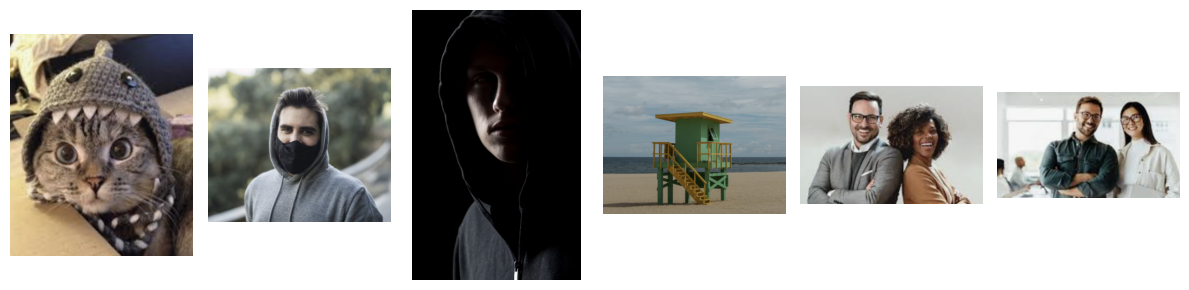

Valid


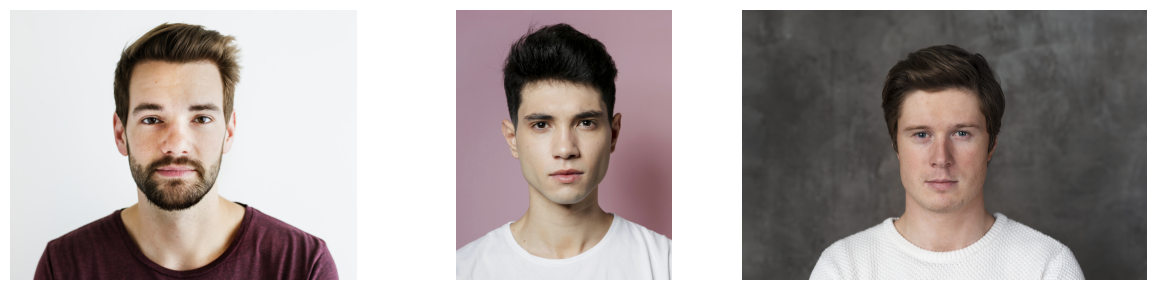

In [124]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt


db_embeddings = torch.load("data/faces/db_embeddings.pt")
new_embeddings = torch.load("data/faces/new_embeddings.pt")

file_path = 'data/faces/new_paths.npy'
new_paths = np.load(file_path)


def display_images(image_paths, figsize=(12, 3)):
    """
    Отображает изображения из списка путей в одну строку (горизонтально)
    """
    num_images = len(image_paths)

    fig, axes = plt.subplots(1, num_images, figsize=figsize)
    fig.subplots_adjust(wspace=0.2)

    # Отображаем изображения
    for i, ax in enumerate(axes.flat):
        if i < num_images:
            img = Image.open(image_paths[i])
            ax.imshow(img)
            ax.axis('off')

    plt.tight_layout()
    plt.show()


def find_invalid_images(new_embeddings, db_embeddings, new_paths, threshold=0.5):
    # Нормализуем эмбеддинги
    db_embeddings = F.normalize(db_embeddings, p=2, dim=1)
    new_embeddings = F.normalize(new_embeddings, p=2, dim=1)
    similarities = cosine_similarity(new_embeddings, db_embeddings).max(axis=1)
    return np.array(new_paths)[similarities <= threshold], similarities


invalid_images, similarities = find_invalid_images(new_embeddings, 
             db_embeddings, new_paths, threshold=0.67)

# Визуализируем фото, не прошедшие проверку
print("Invalid")
display_images(invalid_images)
# Визуализируем фото, прошедшие проверку
print("Valid")
display_images(list(set(new_paths).difference(invalid_images)))